In [5]:
import pandas as pd 

data = {
    'customer_id': [1, 2, 3],
    'purchase1': [100, 200, 150],
    'purchase2': [80, 120, 130]
    }

df = pd.DataFrame(data)

df['total_purchase'] = df ['purchase1']+df['purchase2']
df

#av
df['avg'] = df ['total_purchase'] / 2 
df

,customer_id,purchase1,purchase2,total_purchase,avg
0,1,100,80,180,90.0
1,2,200,120,320,160.0
2,3,150,130,280,140.0


In [ ]:
import pandas as pd

# 예시 데이터프레임 생성
data = {'region': ['A', 'A', 'B', 'B', 'C'],
        'income': [5000, 6000, 5500, 6200, 5800]}
df = pd.DataFrame(data)

# 지역별 평균 소득 계산하여 요약변수(avg_income)으로 생성
avg_income = df.groupby('region')['income'].mean().reset_index()#인덱스 초기화
avg_income.rename(columns={'income':'avg_income'},inplace=True)
avg_income

,region,avg_income
0,A,5500.0
1,B,5850.0
2,C,5800.0


In [10]:
avg_income = df.groupby('region')['income'].transform('mean')
df['avg_income'] = avg_income
df

,region,income,avg_income
0,A,5000,5500.0
1,A,6000,5500.0
2,B,5500,5850.0
3,B,6200,5850.0
4,C,5800,5800.0


In [11]:
import pandas as pd

# 예시 데이터프레임 생성
data = {'person': ['X', 'Y', 'Z'],
        'income': [4000, 5000, 6000]}
df = pd.DataFrame(data)

# 전체 평균 소득 계산
mean_income = df['income'].mean()

#평균 대비 소득 차이 
df['income_diff'] = df['income']- mean_income
df

,person,income,income_diff
0,X,4000,-1000.0
1,Y,5000,0.0
2,Z,6000,1000.0


In [14]:
import pandas as pd

# 예시 데이터프레임 생성
data = {'region': ['A', 'B', 'C', 'D'],
        'avg_income': [5500, 5000, 6000, 4500]}
df = pd.DataFrame(data)

mean_income = df['avg_income'].mean()

def categorize_income(x):
    if x > mean_income:
        return '높음'
    elif x == mean_income:
        return '보통'
    else:
        return '낮음'
df['income_level'] = df['avg_income'].apply(categorize_income)
df

,region,avg_income,income_level
0,A,5500,높음
1,B,5000,낮음
2,C,6000,높음
3,D,4500,낮음


In [15]:
import pandas as pd
import numpy as np

# 예시 데이터프레임 생성
data = {'name': ['Alice', 'Bob', 'Charlie', 'David'],
        'age': [25, np.nan, 30, np.nan]}
df = pd.DataFrame(data)

mean_age = df['age'].mean()

df['age'].fillna(mean_age,inplace= True)
df

/var/folders/g7/6_f4vlmd2tnf4ghbk1n9tv_40000gn/T/ipykernel_97070/3658319608.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(mean_age,inplace= True)


,name,age
0,Alice,25.0
1,Bob,27.5
2,Charlie,30.0
3,David,27.5


In [2]:
import pandas as pd
import numpy as np

# 예시 데이터프레임 생성
data = {'student': ['A', 'B', 'C', 'D', 'E'],
        'score': [80, np.nan, 90, np.nan, 85]}
df = pd.DataFrame(data)


nan_indices = df[df['score'].isnull()].index

df.loc[nan_indices,'score'] = np.random.choice(df['score'].dropna(),size = len(nan_indices))
df

,student,score
0,A,80.0
1,B,85.0
2,C,90.0
3,D,80.0
4,E,85.0


In [ ]:
import pandas as pd
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# 예시 데이터프레임 생성
data = {'feature1': [1.0, 2.1, np.nan, 4.3, 5.2],
        'feature2': [3.2, np.nan, 1.8, 2.5, 4.0]}
df = pd.DataFrame(data)

imputer = IterativeImputer(max_iter=10, random_state=0)

df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
print(df_imputed)

   feature1  feature2
0  1.000000  3.200000
1  2.100000  2.874009
2  3.148439  1.800000
3  4.300000  2.500000
4  5.200000  4.000000


In [5]:
import pandas as pd

# 예시 데이터프레임 생성
data = {'value': [10, 12, 14, 16, 18, 100]}
df = pd.DataFrame(data)

# 사분위수 계산
Q1 = df['value'].quantile(0.25)
Q3 = df['value'].quantile(0.75)
IQR = Q3 - Q1

# 이상값 기준 계산
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 이상값 식별
outliers = df[(df['value'] < lower_bound) | (df['value'] > upper_bound)]
print(outliers)

   value
5    100


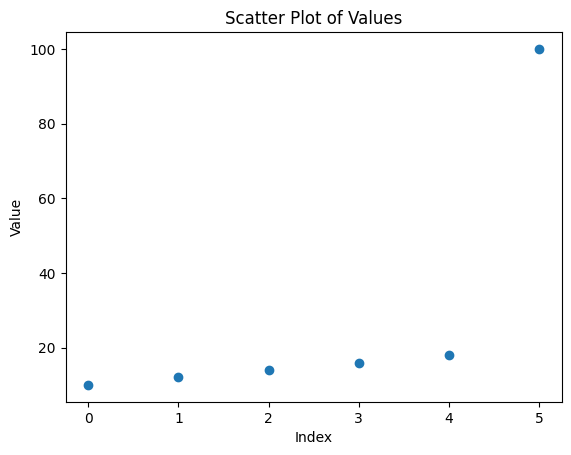

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 예시 데이터프레임 생성
data = {'value': [10, 12, 14, 16, 18, 100]}
df = pd.DataFrame(data)

plt.scatter(df.index,df['value'])
plt.title('Scatter Plot of Values')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

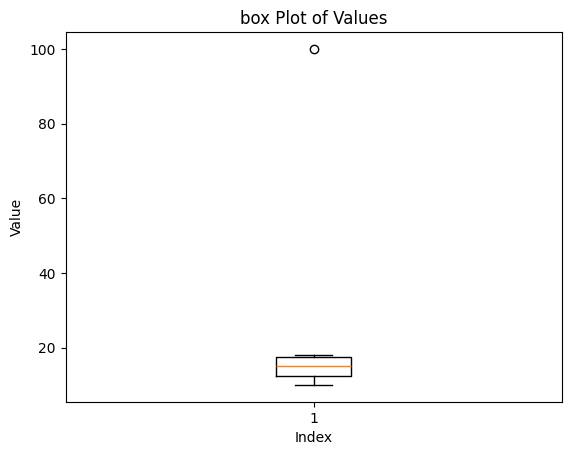

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 예시 데이터프레임 생성
data = {'value': [10, 12, 14, 16, 18, 100]}
df = pd.DataFrame(data)

plt.boxplot(df['value'])
plt.title('box Plot of Values')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

In [8]:
import pandas as pd

# 예시 데이터프레임 생성
data = {'score': [70, 80, 90, 100, 110]}
df = pd.DataFrame(data)

# 평균과 표준편차 계산
mean = df['score'].mean()
std = df['score'].std()

# Z-변환 적용
df['z_score'] = (df['score'] - mean) / std
print(df)

   score   z_score
0     70 -1.264911
1     80 -0.632456
2     90  0.000000
3    100  0.632456
4    110  1.264911


In [ ]:
import pandas as pd

# 예시 데이터프레임 생성
data = {'score': [70, 80, 90, 100, 110]}
df = pd.DataFrame(data)

# 최소값과 최대값 계산
min_val = df['score'].min()
max_val = df['score'].max()

# [0-1] 변환 적용
df['normalized_score'] = (df['score'] - min_val) / (max_val - min_val)
print(df)

#from sklearn.preprocessing import MinMaxScaler
#MinMaxScaler()

   score  normalized_score
0     70              0.00
1     80              0.25
2     90              0.50
3    100              0.75
4    110              1.00


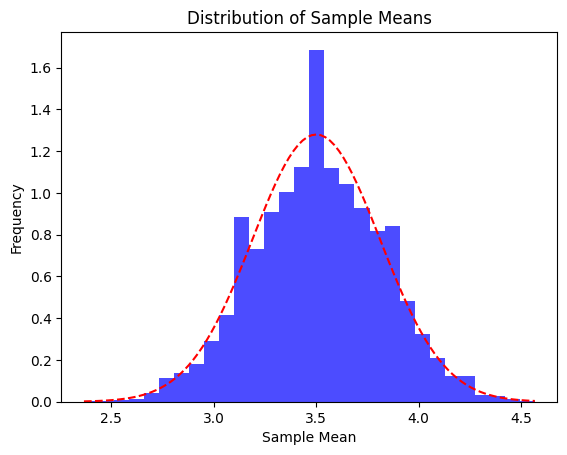

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# 표본 크기와 시도 횟수 설정
n = 30  # 표본 크기
trials = 10000  # 시도 횟수

# 표본평균 저장 리스트
sample_means = []

for _ in range(trials):
    samples = np.random.randint(1, 7, n)  # 주사위 눈 1~6 사이의 정수
    sample_means.append(np.mean(samples))

# 히스토그램 그리기
plt.hist(sample_means, bins=30, density=True, alpha=0.7, color='blue')

# 정규분포 곡선 그리기
from scipy.stats import norm
mu = 3.5  # 주사위 눈의 평균
sigma = np.sqrt(35/12) / np.sqrt(n)  # 주사위 눈의 분산과 표본 크기를 이용한 표준편차
x = np.linspace(min(sample_means), max(sample_means), 100)
plt.plot(x, norm.pdf(x, mu, sigma), 'r--')

plt.title('Distribution of Sample Means')
plt.xlabel('Sample Mean')
plt.ylabel('Frequency')
plt.show() 